# Customer Churn Prediction — Extra Trees Classifier

This notebook covers the end-to-end workflow for the `Churn_Modelling.csv` dataset:

1. **Setup & Data Loading**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing**
4. **Model Training (Extra Trees Classifier)**
5. **Model Evaluation**
6. **Feature Importance**


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [5]:
df = pd.read_csv("C:\\Users\\thish\\Downloads\\churn prediction modeling-20260817T080847Z-1-001\\churn prediction modeling-20260817T080847Z-1-001\\churn prediction modeling\\Churn_Modelling.csv")
print(df.shape)
df.head()


(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Missing Values & Duplicates

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate CustomerId:", df["CustomerId"].duplicated().sum())


Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0
Duplicate CustomerId: 0


### 2.2 Target Variable Distribution

`Exited` is the target: 1 = customer churned, 0 = customer retained. The dataset is expected to be imbalanced.

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: count, dtype: float64


C:\Users\thish\AppData\Local\Temp\ipykernel_10948\4015273012.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Exited", data=df, palette="Set2")


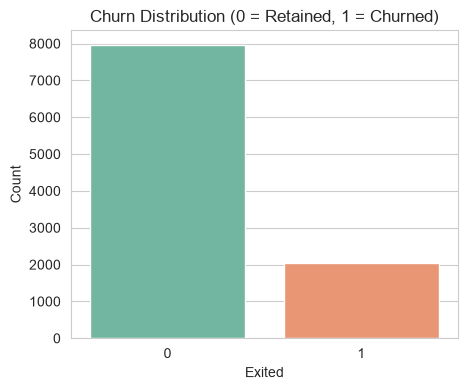

In [9]:
target_counts = df["Exited"].value_counts()
print(target_counts)
print(target_counts / len(df) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x="Exited", data=df, palette="Set2")
plt.title("Churn Distribution (0 = Retained, 1 = Churned)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()


### 2.3 Numerical Feature Distributions

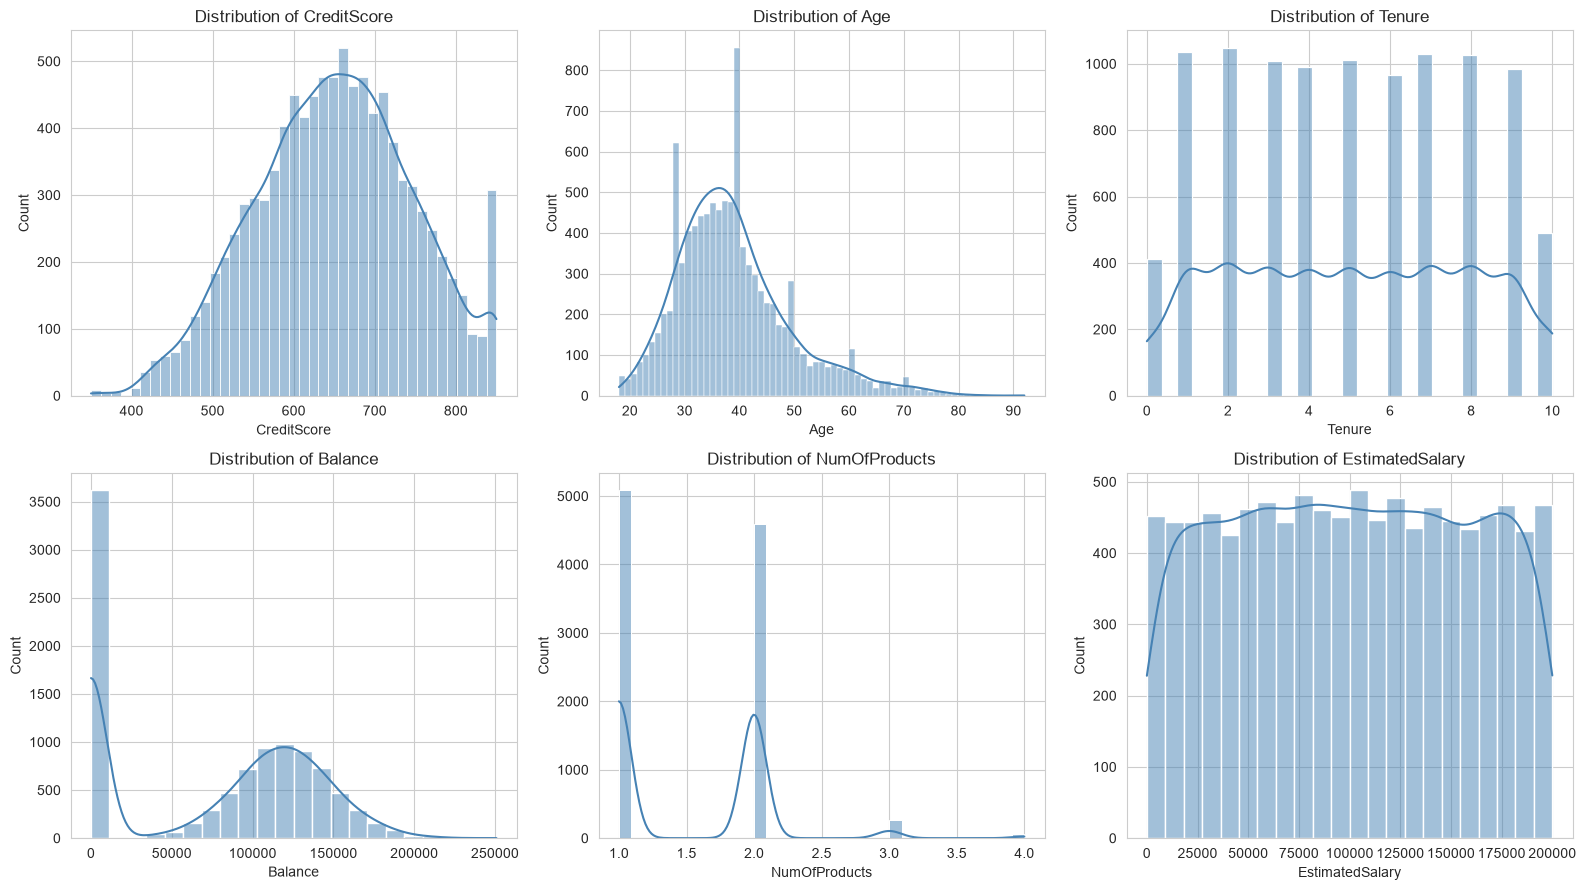

In [10]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 2.4 Numerical Features vs Target

C:\Users\thish\AppData\Local\Temp\ipykernel_10948\364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
C:\Users\thish\AppData\Local\Temp\ipykernel_10948\364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
C:\Users\thish\AppData\Local\Temp\ipykernel_10948\364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
C:\Users\thish\AppData\Local\Temp\ipykernel_10948\36439442

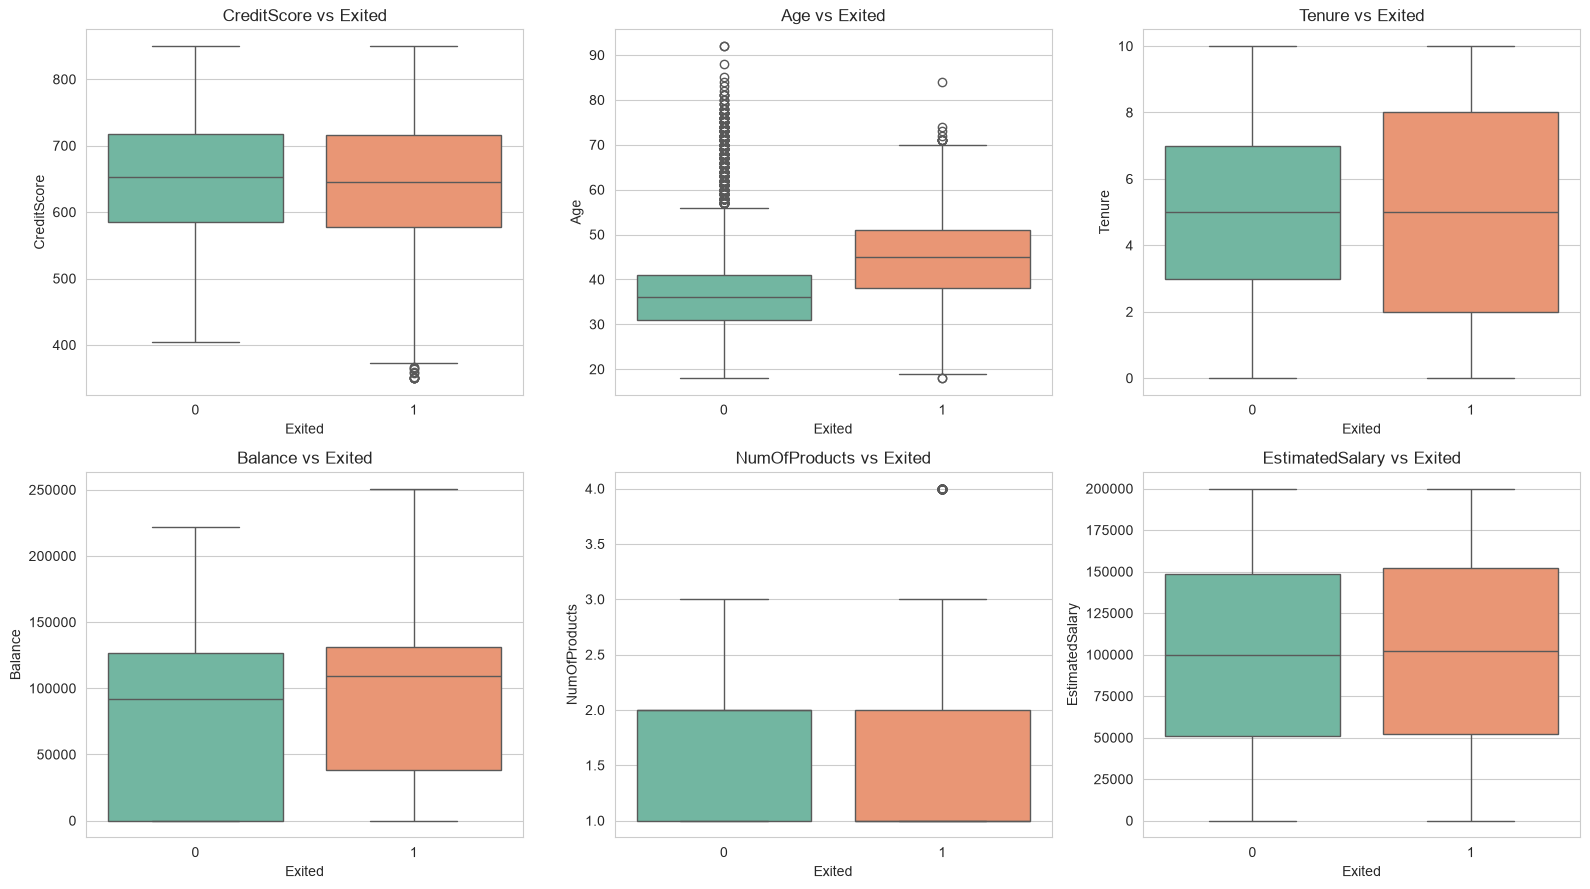

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()


### 2.5 Categorical Feature Distributions vs Target

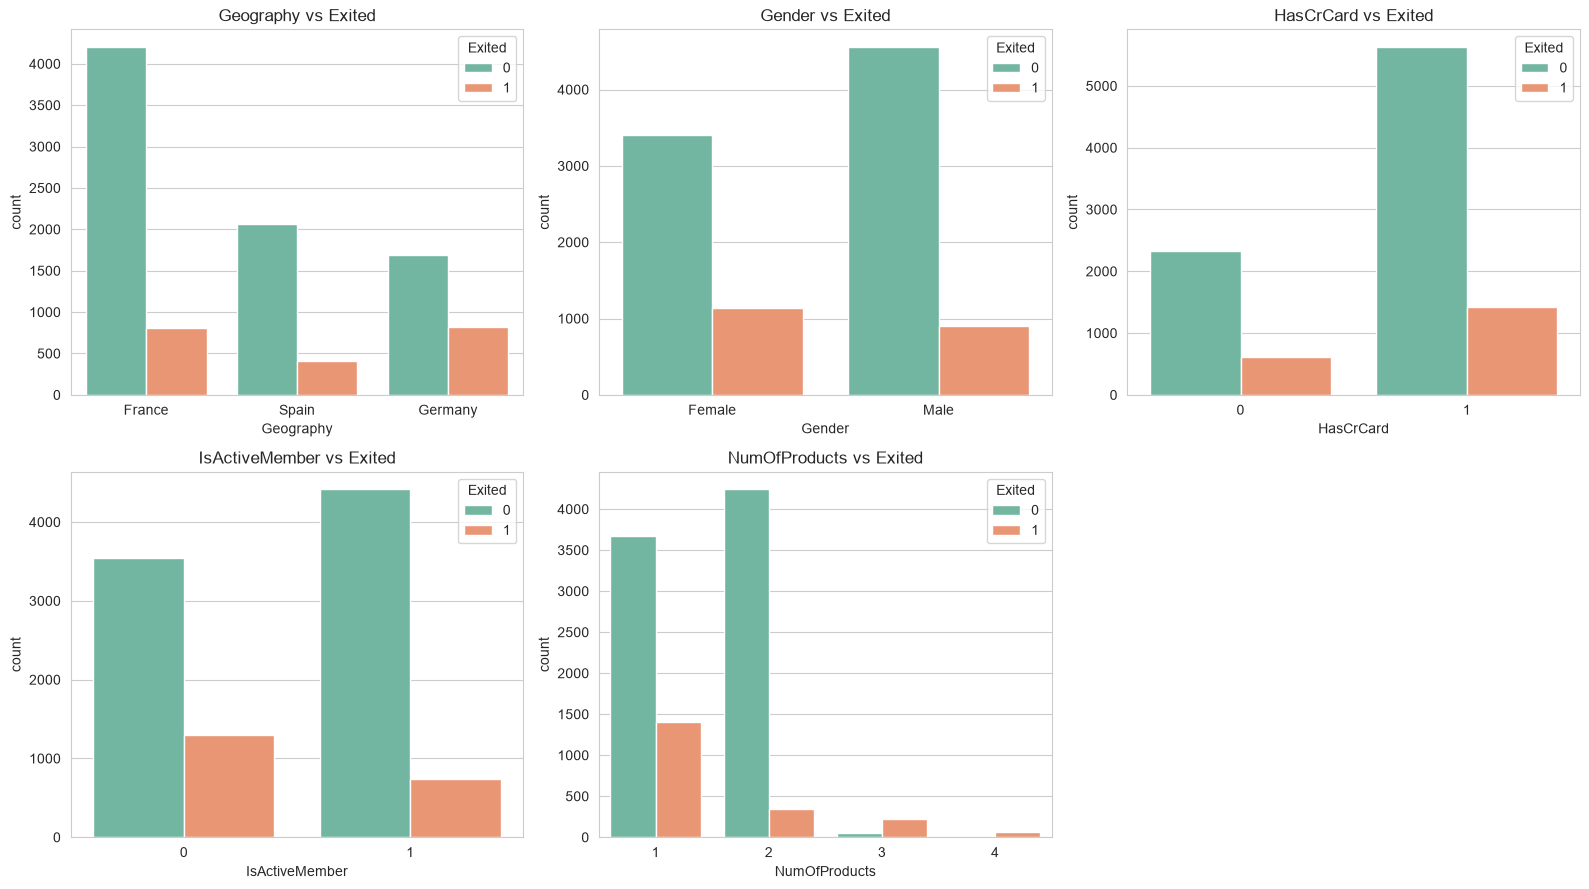

In [12]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue="Exited", data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Exited")

# remove unused subplot
if len(cat_cols) < len(axes.flatten()):
    for extra_ax in axes.flatten()[len(cat_cols):]:
        fig.delaxes(extra_ax)

plt.tight_layout()
plt.show()


### 2.6 Correlation Heatmap (numerical features)

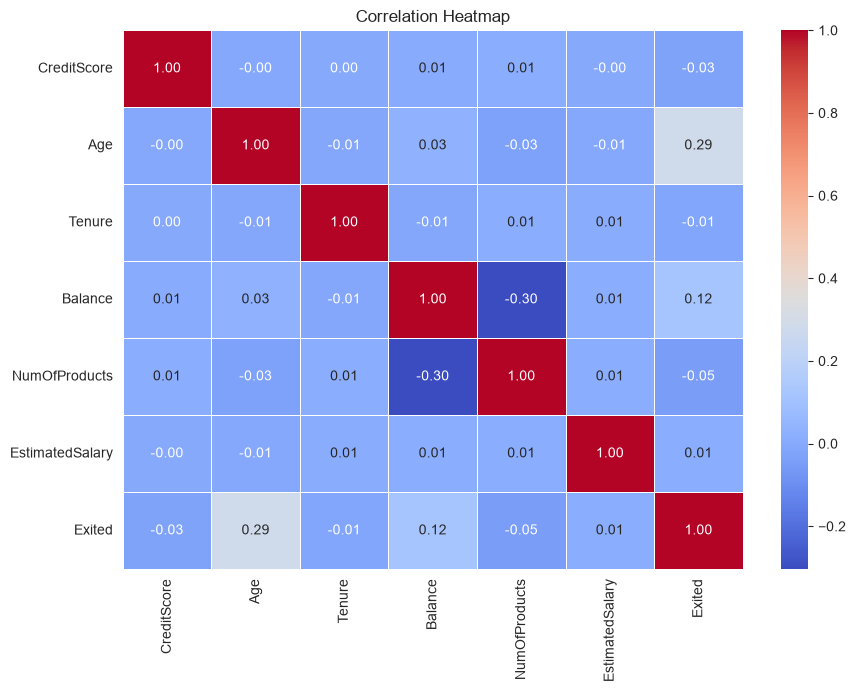

In [13]:
plt.figure(figsize=(10, 7))
corr_cols = num_cols + ["Exited"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


**EDA takeaways** (update after reviewing the plots above):
- Churn is imbalanced (~20% churned vs ~80% retained), so accuracy alone won't be a reliable metric — check precision/recall/F1/ROC-AUC too.
- `Age`, `Geography`, `NumOfProducts`, `IsActiveMember`, and `Balance` tend to show visible differences between churned and retained customers and are likely useful predictors.
- `RowNumber`, `CustomerId`, and `Surname` are identifiers with no predictive value and should be dropped.

## 3. Data Preprocessing

### 3.1 Drop Irrelevant Columns
ID-like columns carry no predictive signal and can leak/overfit if kept.

In [14]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df_model.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.2 Encode Categorical Variables
- `Gender`: binary → Label Encoding
- `Geography`: nominal, >2 categories → One-Hot Encoding

In [15]:
le = LabelEncoder()
df_model["Gender"] = le.fit_transform(df_model["Gender"])  # Female=0, Male=1 (verify with le.classes_)
print("Gender classes:", le.classes_)

df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)
df_model.head()


Gender classes: ['Female' 'Male']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### 3.3 Feature / Target Split

In [16]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

print("Features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)


Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
X shape: (10000, 11) | y shape: (10000,)


### 3.4 Train-Test Split
Stratified split to preserve the churn ratio in both sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), "| Test churn rate:", y_test.mean().round(3))


Train shape: (8000, 11) | Test shape: (2000, 11)
Train churn rate: 0.204 | Test churn rate: 0.204


### 3.5 Feature Scaling
Tree-based models like Extra Trees don't strictly require scaling, but it's included here for completeness (e.g. if you later compare against distance-based models).

In [18]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
2151,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735
8392,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735
5006,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735
4117,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735
7182,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735


## 4. Model Training — Extra Trees Classifier

Extra Trees (Extremely Randomized Trees) builds an ensemble of unpruned decision trees, using random thresholds for splits (instead of searching for the best threshold like Random Forest), which usually reduces variance further.

We train on the **unscaled** features first (scaling doesn't matter for tree-based models), then tune hyperparameters with cross-validation.

In [19]:
et_baseline = ExtraTreesClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"  # helps with the class imbalance
)

et_baseline.fit(X_train, y_train)

train_acc = et_baseline.score(X_train, y_train)
test_acc = et_baseline.score(X_test, y_test)
print(f"Baseline train accuracy: {train_acc:.4f}")
print(f"Baseline test accuracy:  {test_acc:.4f}")


Baseline train accuracy: 1.0000
Baseline test accuracy:  0.8595


### 4.1 Hyperparameter Tuning (GridSearchCV)

In [20]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=ExtraTreesClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC: 0.8563646695110325


In [21]:
best_model = grid_search.best_estimator_
best_model


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when l

## 5. Model Evaluation

In [22]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1-score:", f1_score(y_test, y_pred))
print("Test ROC-AUC :", roc_auc_score(y_test, y_proba))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))


Test Accuracy: 0.833
Test F1-score: 0.6088992974238876
Test ROC-AUC : 0.8535207009783282

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.88      0.89      1593
     Churned       0.58      0.64      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000



### 5.1 Confusion Matrix

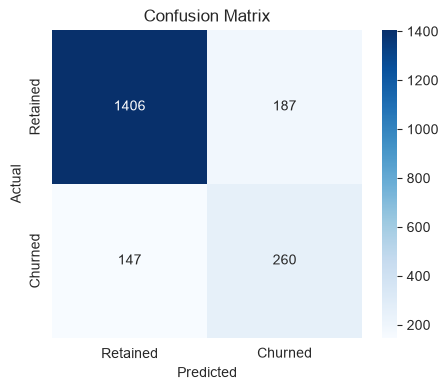

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### 5.2 ROC Curve

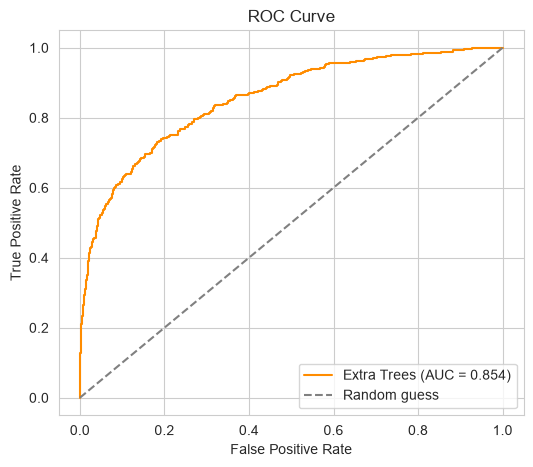

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Extra Trees (AUC = {auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### 5.3 Cross-Validation Sanity Check

In [25]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print("CV ROC-AUC scores:", cv_scores)
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")


CV ROC-AUC scores: [0.85304433 0.8639983  0.85240711 0.85795503 0.84450706]
Mean: 0.8544 | Std: 0.0065


## 6. Feature Importance

C:\Users\thish\AppData\Local\Temp\ipykernel_10948\1360024439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


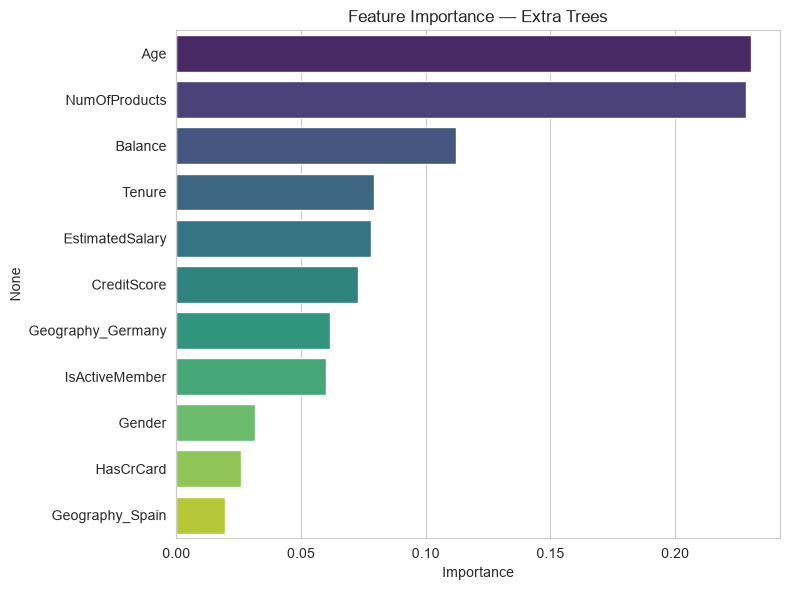

Age                  0.230494
NumOfProducts        0.228361
Balance              0.112018
Tenure               0.079250
EstimatedSalary      0.077969
CreditScore          0.072802
Geography_Germany    0.061787
IsActiveMember       0.060055
Gender               0.031708
HasCrCard            0.025839
Geography_Spain      0.019717
dtype: float64

In [26]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance — Extra Trees")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances
